##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: facebook/deit-small-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Ground Truth Labels : [1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0]
Predicted Clusters  : [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]

Best Clustering Accuracy: 0.55


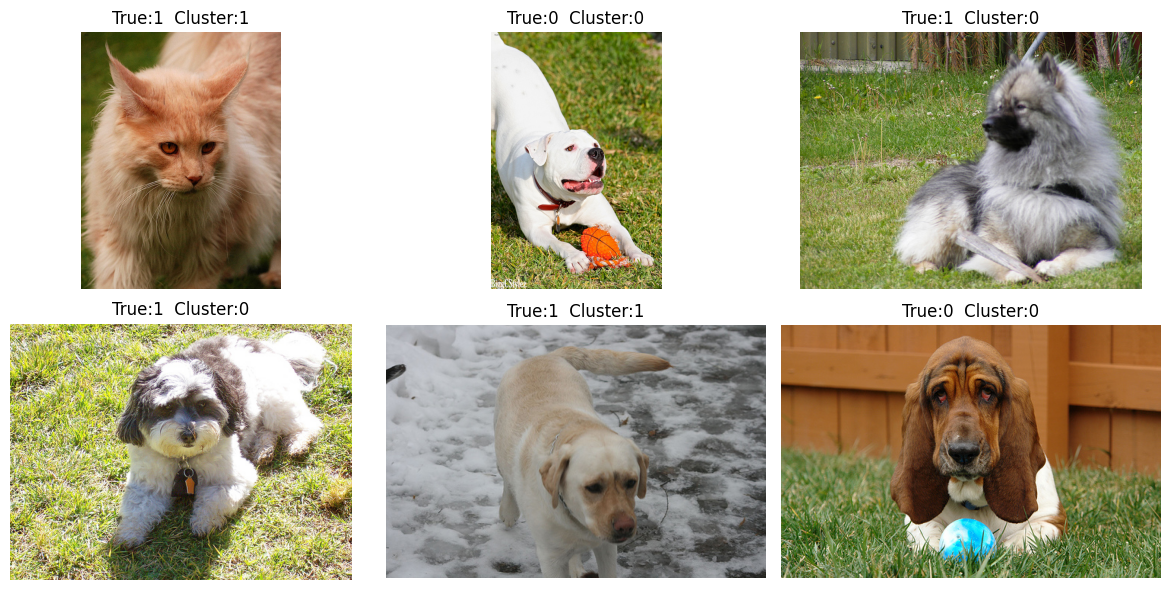

In [1]:
!pip -q install datasets transformers scikit-learn pillow matplotlib

from datasets import load_dataset
from transformers import AutoImageProcessor, ViTModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load Oxford-IIIT Pet dataset
dataset = load_dataset("timm/oxford-iiit-pet")["train"]

# Take 20 images (mix cats and dogs)
images = []
labels = []

for item in dataset:
    label = item["label"]
    # labels 0-11 = cats, 12-36 = dogs
    binary_label = 0 if label < 12 else 1

    if labels.count(0) < 10 and binary_label == 0:
        images.append(item["image"])
        labels.append(0)

    elif labels.count(1) < 10 and binary_label == 1:
        images.append(item["image"])
        labels.append(1)

    if len(images) == 20:
        break

# Load ViT model
processor = AutoImageProcessor.from_pretrained("facebook/deit-small-patch16-224")
model = ViTModel.from_pretrained("facebook/deit-small-patch16-224")

# Extract CLS tokens
features = []

for img in images:
    inputs = processor(images=img, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    cls_token = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
    features.append(cls_token)

features = np.array(features)

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(features)

# Match cluster IDs to labels
acc1 = accuracy_score(labels, clusters)
acc2 = accuracy_score(labels, 1 - clusters)
best_acc = max(acc1, acc2)

print("Ground Truth Labels :", labels)
print("Predicted Clusters  :", clusters.tolist())
print(f"\nBest Clustering Accuracy: {best_acc:.2f}")

# Visualize first 6 images
plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(f"True:{labels[i]}  Cluster:{clusters[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

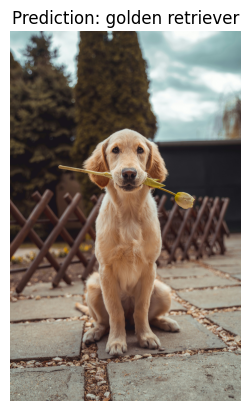

Predicted Class: golden retriever


In [2]:

!pip -q install transformers pillow requests matplotlib

from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt

# Model ID from the exercise
model_id = "facebook/dinov2-small-imagenet1k-1-layer"

# Load model and processor
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForImageClassification.from_pretrained(model_id)

# Image from online (Golden Retriever)
url = "https://images.unsplash.com/photo-1552053831-71594a27632d"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Preprocess image
inputs = processor(images=image, return_tensors="pt")

# Prediction
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class_idx]

# Show result
plt.imshow(image)
plt.title(f"Prediction: {predicted_label}")
plt.axis("off")
plt.show()

print("Predicted Class:", predicted_label)